mass: 12.861412657852622 kg
weight (lbs):  127.56242757375504
Error Vector: []
num timesteps: 10000
43.26935625076294


Text(0.5, 0, 's')

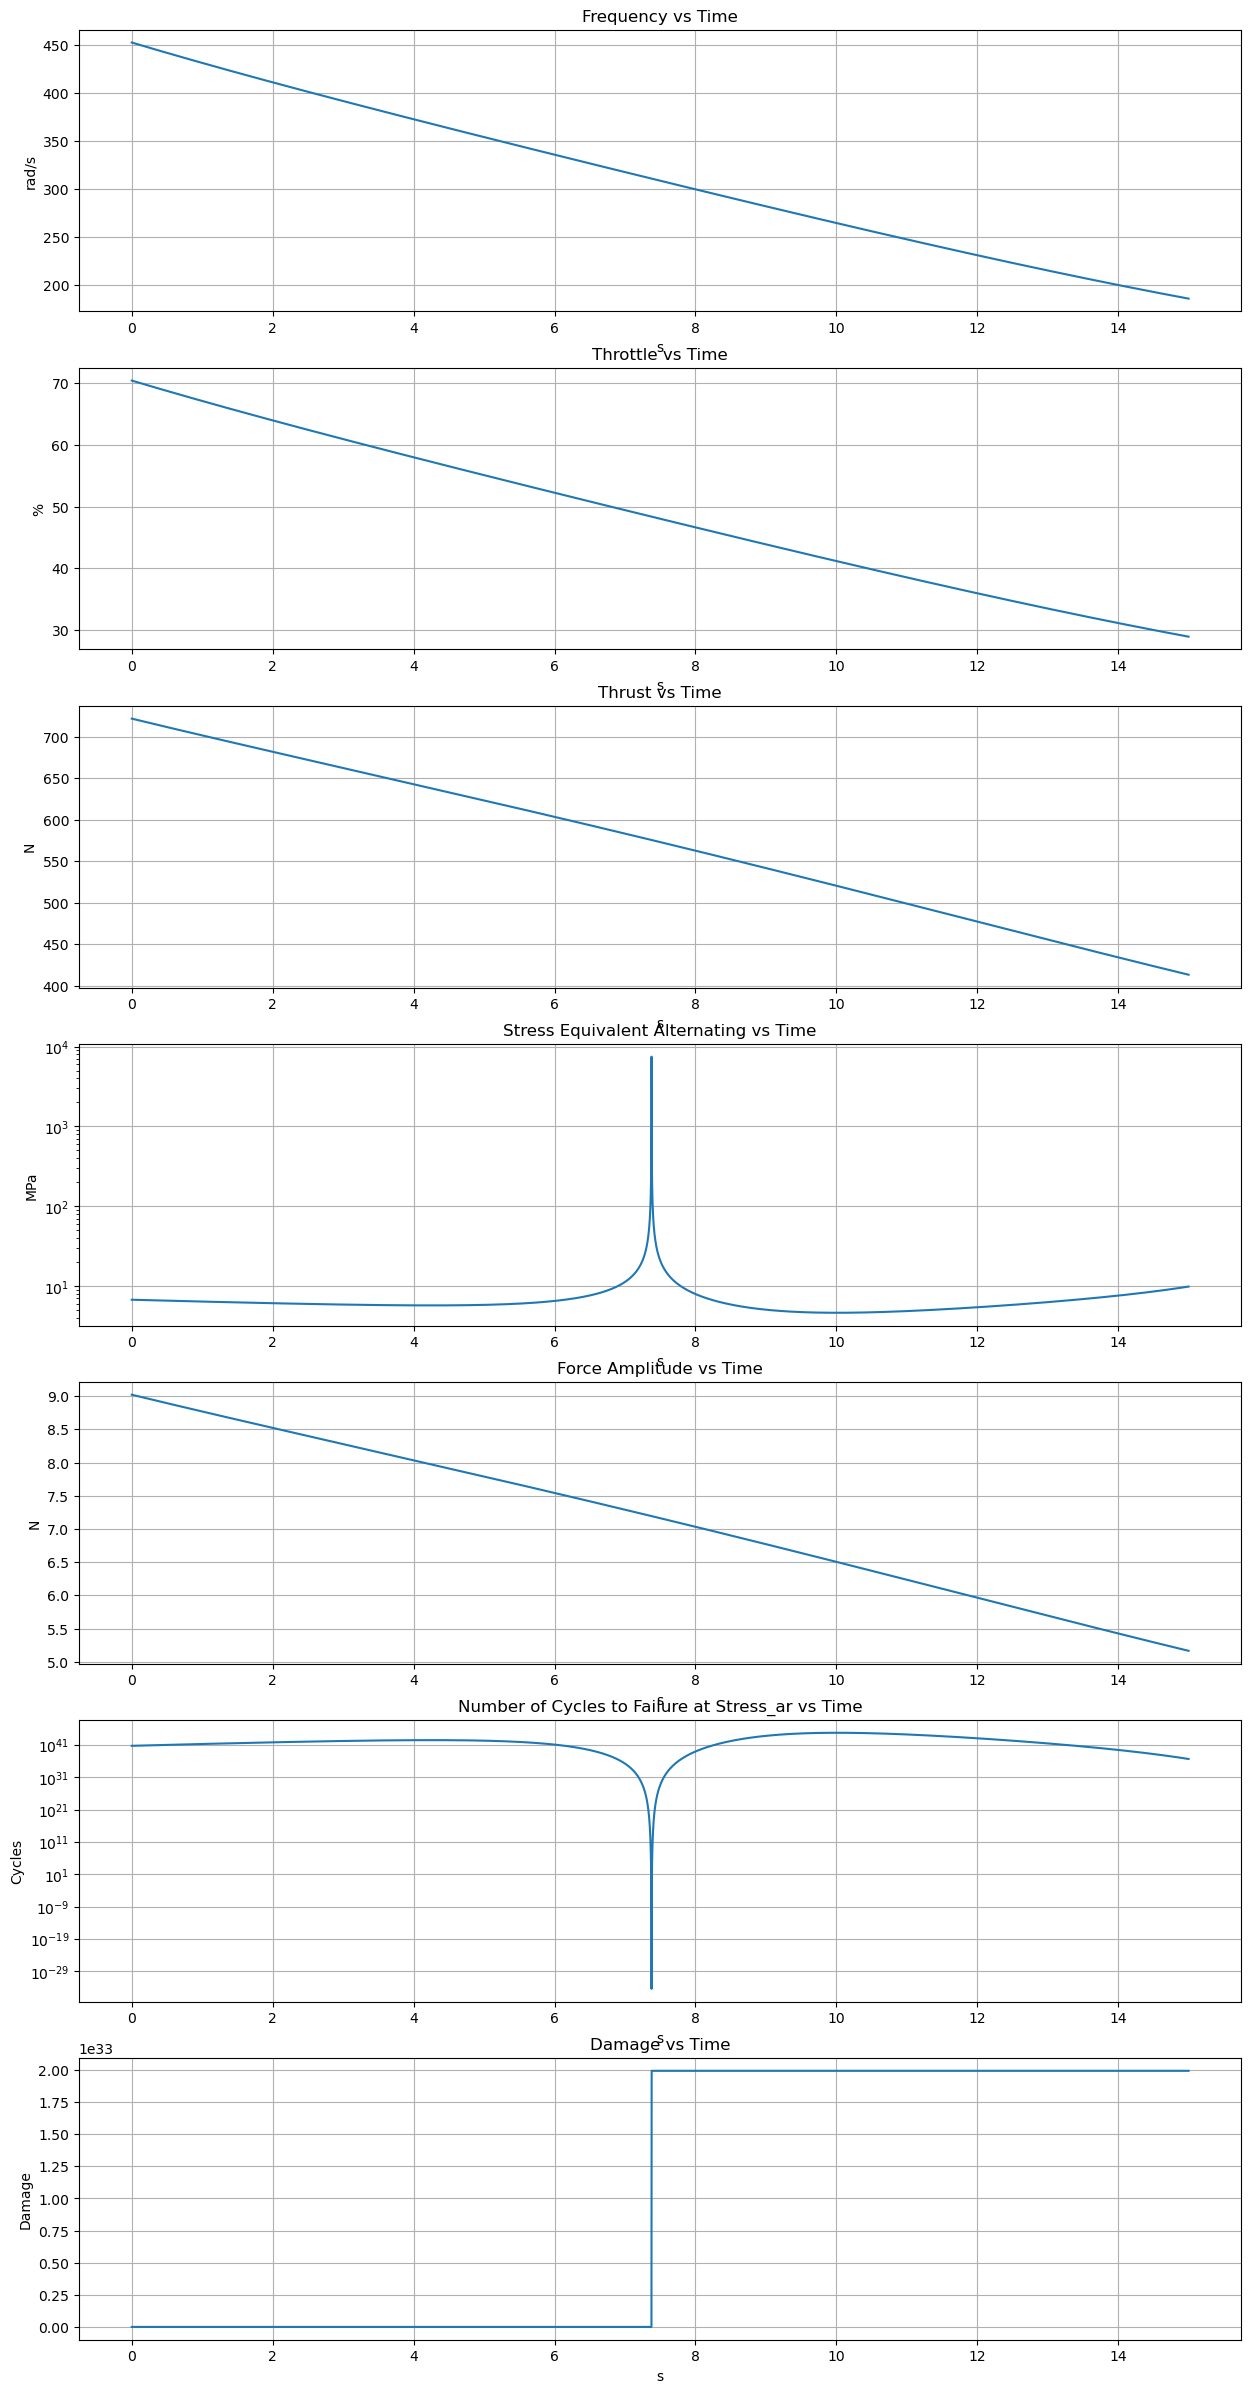

In [3]:
import math
import numpy as np
import matplotlib.pyplot as plt
from Scripts.drone_mass import DroneMass
from Scripts.drone_battery import Battery
from Scripts.drone_geometry import DroneGeometry
from Scripts.beams import BeamType
from Scripts.mission_profile import MissionProfile
from Scripts.drone_power import DronePower
from Scripts.drone_power import BatterySystem
from Scripts.drone_fea import DroneFEA
from Scripts.drone_forces import DroneForces
import Scripts.unit_conversions as uc
import time

timer0 = time.time()
drag_coeff = 0.256

Propeller_radius = 406.4
# spacing between propellers
Propeller_spacing = 25
arm_length = (Propeller_spacing + Propeller_radius) / math.sin(22.5 * math.pi/180)

# Mass Analysis Setup
battery_1 = Battery(4.292e-3, np.array([0, 86.75, -50]), np.array([260.5, 123.5, 63.5]))
battery_2 = Battery(4.292e-3, np.array([0, -86.75, -50]), np.array([260.5, 123.5, 63.5]))
arm_beam = BeamType("annulus", [29, 25], "Aluminum7075-T6", "arm_beam")
strut_beam = BeamType("annulus", [14, 12], "Aluminum7075-T6", "strut_beam")
d1 = DroneGeometry("drone_test", 1000, 660, 8, arm_beam, strut_beam, [battery_1, battery_2])
d1_mass = DroneMass(d1)

# Mass Analysis results
print("mass:", d1_mass.total_mass * 1000, "kg")
total_mass = d1_mass.total_mass + (45 * 10 ** -3)
print("weight (lbs): ", total_mass * uc.Mg_to_lb)
surface_area = d1.projected_surface_area

# Mission Profile generation
m1 = MissionProfile("m1", 1, 0, 0)
# m1.add_segment("takeoff",2,0,2,0,1)
m1.add_segment("climb",15,550000,100000,300,0)
# m1.add_segment("cruise",50,2000000,110000,300,0)
# m1.add_segment("descent",10,2200000,50000,0,0)
# m1.add_segment("loiter",5,2200000,50000,0,0)
# m1.add_segment("land",10,2400000,0,0,0)

# Drone Force Analysis
d1_forces = DroneForces(total_mass, surface_area, drag_coeff, m1)

# Drone
battery_sys = BatterySystem("Tattu 40000mAh 6S 10C 22.8V High Voltage UAV Lipo Battery Pack with AS150+AS150", 22.8, 40000, 2)
drone_power = DronePower(8, battery_sys.milliwatt_hours, d1_forces)

drone_power.energy_consumption_calc(m1.t_values, 10000)
drone_power.throttle_ratio_trans_calc(16) # Power for max throttle in kw w/ full battery
drone_power.freq_trans_calc(3068)

print("Error Vector:", drone_power.error)


# Calc Thrust
forces = np.zeros(len(drone_power.timesteps))
ar = np.zeros(len(drone_power.timesteps))
cycle_num = np.zeros(len(drone_power.timesteps))
damage = np.zeros(len(drone_power.timesteps))
print("num timesteps:", len(drone_power.timesteps))
damage_init = 0
for i ,t in enumerate(drone_power.timesteps): 
    forces[i], drag = d1_forces.time_solve(t)
    
    x = np.array([45, 1, 45, 3, 500])
    arm_d1,arm_t,strut_d1,strut_t,strut_dist = [x[0],x[1],x[2],x[3],x[4]]

    arm_beam_properties = BeamType("annulus", [arm_d1 + arm_t*2, arm_d1 ], "Carbon Fiber", "arm_beam")
    strut_beam_properties = BeamType("annulus", [strut_d1 + strut_t*2, strut_d1 ], "Carbon Fiber", "strut_beam")
    
    drone_geometry = DroneGeometry("drone", arm_length, strut_dist, 8, arm_beam_properties, strut_beam_properties, [battery_1, battery_2])
    
    d1_fea = DroneFEA(drone_geometry)
    d1_fea.create_drone_slice_nodes() # nominal radius | strut rad | number of blades
    d1_fea.create_drone_slice_beams() # arm beam | strut beam
    d1_fea.boundary_conditions_slice()
    d1_fea.beam_system.add_force(np.array([0,0,-forces[i]/8]),"outer_node")
    d1_fea.beam_system.init_dynamic_forces(drone_power.frequency[i])
    d1_fea.beam_system.add_dynamic_harmonic_force(np.array([0,0,-forces[i]/80,0,0,0]),"outer_node")
    d1_fea.solve_fea()
    d1_fea.solve_static()
    d1_fea.solve_dynamic_harmonic(1.52,0.00024)
    d1_fea.beam_system.solve_failure_swt()
    
    ar[i] = d1_fea.beam_system.beams[1].stress_equivalent_alternating_0
    cycle_num[i] = d1_fea.beam_system.beams[1].cycle_num_0
    
    if i == 0:
        damage[i] = damage_init
    else:
        timestep_length = drone_power.timesteps[i] - drone_power.timesteps[i-1]
        cycle_count = drone_power.frequency[i] * uc.rad_per_s_to_Hz * timestep_length 
        damage[i] = damage[i-1] + (cycle_count/d1_fea.beam_system.beams[1].cycle_num_0)



timer1 = time.time()
print(timer1-timer0)

# Plotting
fig, axs = plt.subplots(7,1)

fig.set_figheight(30)
fig.set_figwidth(15)

axs[0].set_title("Frequency vs Time")
axs[0].plot(drone_power.timesteps, drone_power.frequency)
axs[0].grid()
axs[0].set_ylabel("rad/s")
axs[0].set_xlabel("s")

axs[1].set_title("Throttle vs Time")
axs[1].plot(drone_power.timesteps, drone_power.percent_throttle * 100)
axs[1].grid()
axs[1].set_ylabel("%")
axs[1].set_xlabel("s")

axs[2].set_title("Thrust vs Time")
axs[2].plot(drone_power.timesteps, forces)
axs[2].grid()
axs[2].set_ylabel("N")
axs[2].set_xlabel("s")

axs[3].set_yscale('log')
axs[3].set_title("Stress Equivalent Alternating vs Time")
axs[3].plot(drone_power.timesteps, ar)
axs[3].grid()
axs[3].set_ylabel("MPa")
axs[3].set_xlabel("s")


axs[4].set_title("Force Amplitude vs Time")
axs[4].plot(drone_power.timesteps, forces/80)
axs[4].grid()
axs[4].set_ylabel("N")
axs[4].set_xlabel("s")

axs[5].set_yscale('log')
axs[5].set_title("Number of Cycles to Failure at Stress_ar vs Time")
axs[5].plot(drone_power.timesteps, cycle_num)
axs[5].grid()
axs[5].set_ylabel("Cycles")
axs[5].set_xlabel("s")


axs[6].set_title("Damage vs Time")
axs[6].plot(drone_power.timesteps, damage)
axs[6].grid()
axs[6].set_ylabel("Damage")
axs[6].set_xlabel("s")


# Bar chart needed